In [ ]:
import tensorflow as tf
print(tf.__version__)

import keras
print(keras.__version__)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from keras import layers, models, applications
from keras.utils import to_categorical, plot_model
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Dropout
from keras.applications import ResNet50

import os

from google.colab import drive  # Import the drive library

# Mount Google Drive
drive.mount('/content/drive')  # Mount to access files

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

2.20.0
3.13.2
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Num GPUs Available:  1


In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/GTSRBDataset/dataset.zip'
extract_path = '/content/GTSRB/Train/Train'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset unzipped successfully!")

Dataset unzipped successfully!


In [ ]:
data = []
labels = []
classes = 43

for i in range(classes):
    path = os.path.join(extract_path, str(i))
    images = os.listdir(path)

    for a in images:
        try:
            image = Image.open(os.path.join(path, a))
            image = image.resize((32, 32))
            image = np.array(image)

            data.append(image)
            labels.append(i)

        except Exception as e:  # Added Exception handling and print error message
            print(f"Error loading image: {a}, Error: {e}")

data = np.array(data)
labels = np.array(labels)

print(data.shape, labels.shape)

# Preprocessing data - Normalizing and resize
data = data / 255.0
# labels = labels / 255.0

# Splitting training and testing dataset
X_t1, X_t2, y_t1, y_t2 = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42
)

print(X_t1.shape, X_t2.shape, y_t1.shape, y_t2.shape)

# Converting labels into one hot encoding
num_classes = len(np.unique(y_t1))

y_t1 = to_categorical(y_t1, num_classes)
y_t2 = to_categorical(y_t2, num_classes)

print(num_classes)

(39209, 32, 32, 3) (39209,)
(31367, 32, 32, 3) (7842, 32, 32, 3) (31367,) (7842,)
43


In [ ]:
# Data Augmentation Layer Integration into Training Process

# Data Augmentation with adding random flips and rotations
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
])

# Apply data augmentation to the training dataset only
augmented_images = []

for image in X_t1:
    augmented_images.append(
        data_augmentation(image, training=True)
    )

## **Model 1: RandomForest**

In [ ]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Flatten the images
X_train_flat = X_t1.reshape(X_t1.shape[0], -1)
X_test_flat = X_t2.reshape(X_t2.shape[0], -1)

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_flat, np.argmax(y_t1, axis=1))

# Predict
y_pred_rf = rf_model.predict(X_test_flat)

# Calculate accuracy
accuracy = accuracy_score(
    np.argmax(y_t2, axis=1),
    y_pred_rf
)

print(f"Random Forest Accuracy: {accuracy}")

Random Forest Accuracy: 0.9811272634532007


## **Model 2: K-Nearest Neighbors (KNN)**

In [ ]:
# K-Nearest Neighbors (KNN)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Train KNN Model
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model = knn_model.fit(
    X_train_flat,
    np.argmax(y_t1, axis=1)
)

# Predict
y_pred_knn = knn_model.predict(X_test_flat)

# Calculate accuracy
accuracy = accuracy_score(
    np.argmax(y_t2, axis=1),
    y_pred_knn
)

print(f"KNN Accuracy: {accuracy}")

KNN Accuracy: 0.8692935475643968


## **Model 3: Transfer Learning--MobileNetV2**

/tmp/ipykernel_9104/2938488895.py:11: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 56s 39ms/step - accuracy: 0.6261 - loss: 1.2296 - val_accuracy: 0.7293 - val_loss: 0.8570
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8061 - loss: 0.5889 - val_accuracy: 0.7744 - val_loss: 0.7146
Epoch 3/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8684 - loss: 0.3968 - val_accuracy: 0.8090 - val_loss: 0.6028
Epoch 4/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9002 - loss: 0.3023 - val_accuracy: 0.8300 - val_loss: 0.5806
Epoch 5/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9224 - loss: 0.2280 - val_accuracy: 0.8347 - val_loss: 0.5924
Epoch 6/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9393 - loss: 0.1830 - val_accuracy: 0.8403 - val_loss: 0.5830
Epoch 7/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9472 - loss: 0.1590 - val_accuracy: 0.8497 - val_loss: 0.5777
Epoch 8/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9519 - loss: 0.1442 - val_ac

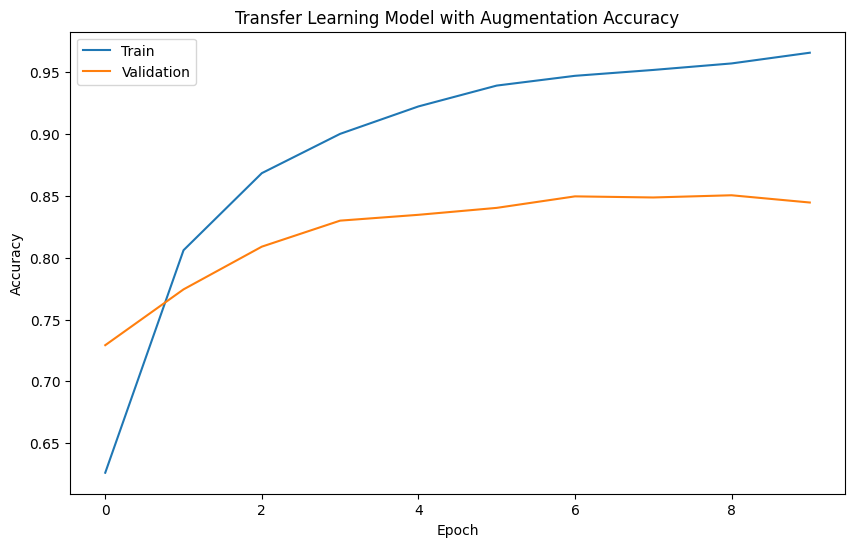

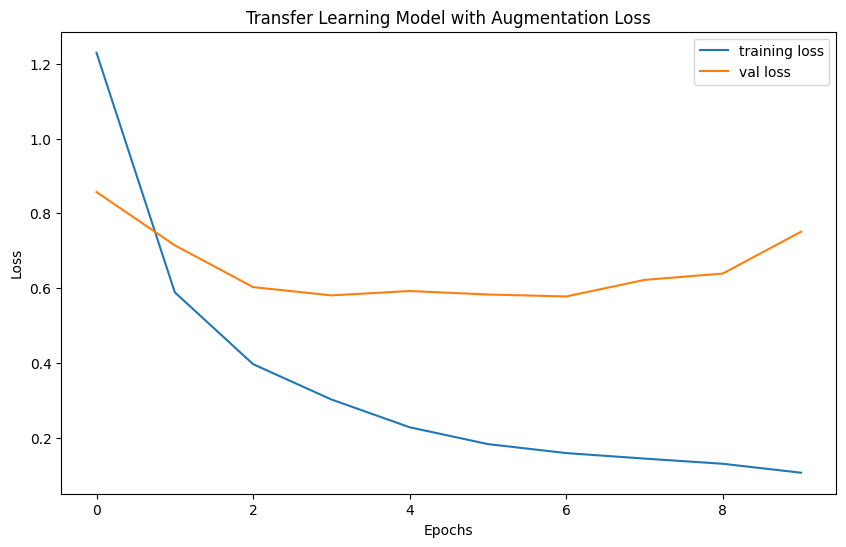

In [ ]:
#96 Transfer Learning with MobileNetV2

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model

# Resize images for MobileNetV2
X_train_resized = np.array([tf.image.resize(image, (64,64)) for image in X_t1])
X_test_resized = np.array([tf.image.resize(image, (64,64)) for image in X_t2])

# Load Pre-trained MobileNetV2
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(64,64, 3)
)

# Add custom classification layers
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(num_classes, activation='softmax')(x)

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=output
)

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = mobilenet_model.fit(
    X_train_resized,
    y_t1,
    batch_size=32,
    epochs=10,
    validation_data=(X_test_resized, y_t2)
)

# Predict
pred_mobilenet = mobilenet_model.predict(X_test_resized)
y_pred_mobilenet = np.argmax(pred_mobilenet, axis=1)

# Plot training & validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Transfer Learning Model with Augmentation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Transfer Learning Model with Augmentation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

mobilenet_model.save('Transfer_Learning.keras')

## **Model 4: Convolutional Neural Network (CNN)**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,939 (1.36 MB)

 Trainable params: 356,939 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
7842/7842 ━━━━━━━━━━━━━━━━━━━━ 51s 5ms/step - accuracy: 0.6711 - loss: 1.1633 - val_accuracy: 0.9508 - val_loss: 0.1545
Epoch 2/10
7842/7842 ━━━━━━━━━━━━━━━━━━━━ 34s 4ms/step - accuracy: 0.9267 - loss: 0.2373 - val_accuracy: 0.9801 - val_loss: 0.0664
Epoch 3/10
7842/7842 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - accuracy: 0.9479 - loss: 0.1699 - val_accuracy: 0.9814 - val_loss: 0.0686
Epoch 4/10
7842/7842 ━━━━━━━━━━━━━━━━━━━━ 34s 4ms/step - accuracy: 0.9559 - loss: 0.1500 - val_accuracy: 0.9836 - val_loss: 0.0609
Epoch 5/10
7842/7842 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - accuracy: 0.9590 - loss: 0.1376 - val_accuracy: 0.9879 - val_loss: 0.0419
Epoch 6/10
7842/7842 ━━━━━━━━━━━━━━━━━━━━ 34s 4ms/step - accuracy: 0.9640 - loss: 0.1289 - val_accuracy: 0.9903 - val_loss: 0.0340
Epoch 7/10
7842/7842 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - accuracy: 0.9651 - loss: 0.1303 - val_accuracy: 0.9855 - val_loss: 0.0527
Epoch 8/10
7842/7842 ━━━━━━━━━━━━━━━━━━━━ 34s 4ms/step - accuracy: 0.9644 - loss: 0

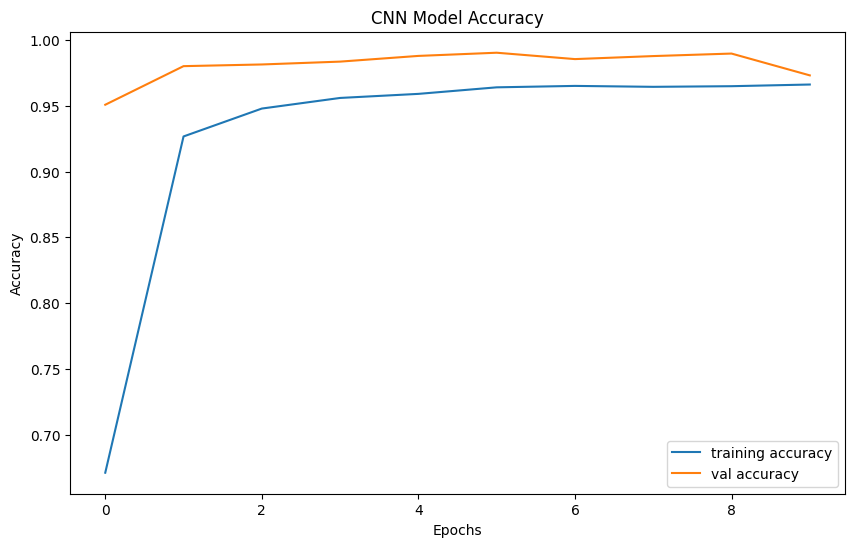

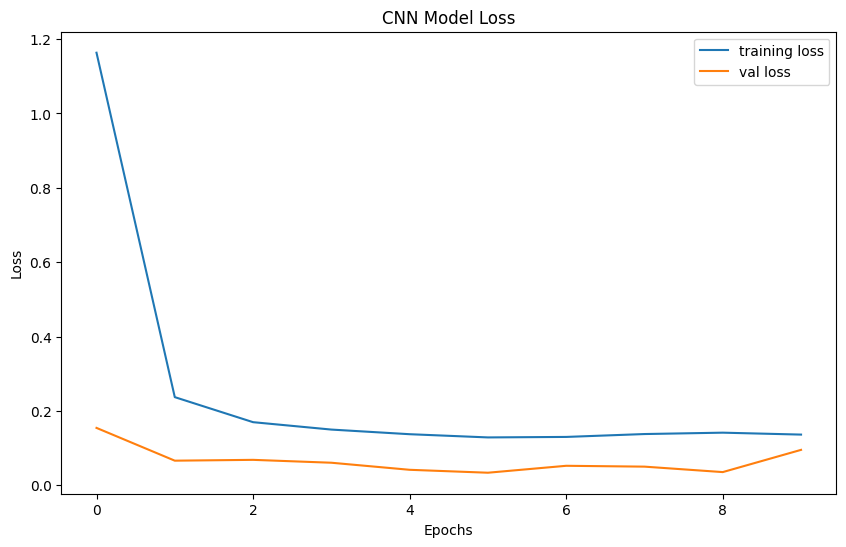

In [ ]:
# Building the CNN Model
cnn_model = Sequential()

cnn_model.add(Conv2D(filters=32, kernel_size=(5,5),
                     activation='relu',
                     input_shape=X_t1.shape[1:]))

cnn_model.add(Conv2D(filters=32, kernel_size=(5,5),
                     activation='relu'))

cnn_model.add(MaxPool2D(pool_size=(2,2)))
cnn_model.add(Dropout(rate=0.25))

cnn_model.add(Conv2D(filters=64, kernel_size=(3,3),
                     activation='relu'))

cnn_model.add(Conv2D(filters=64, kernel_size=(3,3),
                     activation='relu'))

cnn_model.add(MaxPool2D(pool_size=(2,2)))
cnn_model.add(Dropout(rate=0.25))

cnn_model.add(Flatten())

cnn_model.add(Dense(256, activation='relu'))
cnn_model.add(Dropout(rate=0.25))

cnn_model.add(Dense(num_classes, activation='softmax'))

cnn_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

cnn_model.summary()

# Plot the model
plot_model(cnn_model,
           show_shapes=True,
           show_dtype=True)

cnn_model.save('Building_CNN.keras')

# Model training and validation
history = cnn_model.fit(
    X_t1,
    y_t1,
    batch_size=4,
    epochs=10,
    validation_data=(X_t2, y_t2)
)

# Predict
pred_cnn = cnn_model.predict(X_t2)
y_pred_cnn = np.argmax(pred_cnn, axis=1)

cnn_model.save('CNN_Model.keras')

# Plot accuracy graph
plt.figure(figsize=(10, 6))

plt.plot(history.history['accuracy'],
         label='training accuracy')

plt.plot(history.history['val_accuracy'],
         label='val accuracy')

plt.title('CNN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss graph
plt.figure(figsize=(10, 6))

plt.plot(history.history['loss'],
         label='training loss')

plt.plot(history.history['val_loss'],
         label='val loss')

plt.title('CNN Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## **Model 5: K-Means Clustering**

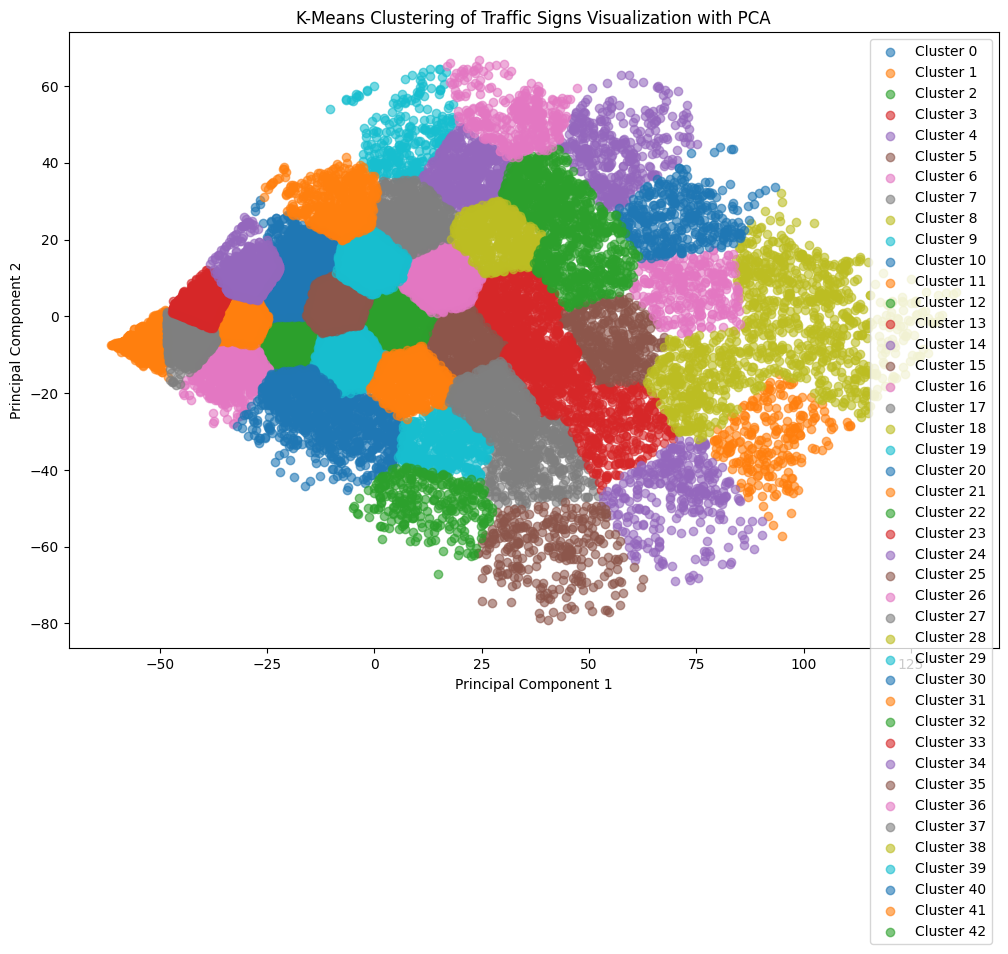

Silhouette Score: 0.34


In [ ]:
# Clustering the traffic signs using K-Means Clustering

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


# Reshape X_t1 into a 2D array before applying StandardScaler
X_t1_reshaped = X_t1.reshape(X_t1.shape[0], -1)


# Standardize the data
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X_t1_reshaped)


# Dimensionality Reduction for Visualization using PCA
# Reduce dimensions to 2D for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_normalized)


# Define the number of clusters for GTSRB
kmeans = KMeans(n_clusters=num_classes, random_state=42)

# Fit the K-Means model
kmeans.fit(X_train_pca)

# Assign clusters to images
clusters = kmeans.labels_


# Visualize Clusters
plt.figure(figsize=(12, 8))

for i in range(num_classes):
    plt.scatter(
        X_train_pca[clusters == i, 0],
        X_train_pca[clusters == i, 1],
        label=f'Cluster {i}',
        alpha=0.6
    )

plt.title('K-Means Clustering of Traffic Signs Visualization with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()


# Compute cluster quality
silhouette_avg = silhouette_score(X_train_pca, clusters)

print(f'Silhouette Score: {silhouette_avg:.2f}')

## **Models Evaluation**

In [ ]:
# ==========================================
# Step 4 : Models Evaluation
# ==========================================

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt


def evaluate_model(model_name, y_pred, y_true):

    # Convert one-hot encoded labels to integers
    y_true = np.argmax(y_true, axis=1)

    acc = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_true,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average='weighted'
    )

    print("\n==============================")
    print(f"{model_name}")
    print("==============================")

    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\nClassification Report")
    print(classification_report(y_true, y_pred))


    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(12,10))

    sns.heatmap(
        cm,
        cmap='Blues'
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"{model_name} Confusion Matrix")

    plt.show()


    return acc, precision, recall, f1

In [ ]:
from scipy.stats import mode


def compute_purity(y_true, clusters, n_clusters):

    majority_sum = 0


    for cluster in range(n_clusters):

        idx = np.where(clusters == cluster)[0]

        if len(idx) > 0:

            majority = mode(
                y_true[idx],
                keepdims=True
            )[0][0]


            majority_sum += (
                y_true[idx] == majority
            ).sum()


    purity = majority_sum / len(y_true)

    return purity


y_train_labels = np.argmax(y_t1, axis=1)

purity = compute_purity(
            y_train_labels,
            clusters,
            num_classes
         )

print(f"Purity Score : {purity:.4f}")

Purity Score : 0.1194



Random Forest
Accuracy  : 0.9811
Precision : 0.9813
Recall    : 0.9811
F1 Score  : 0.9811

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.87      0.93        38
           1       0.96      0.98      0.97       496
           2       0.96      0.96      0.96       450
           3       0.97      0.94      0.96       280
           4       0.96      0.98      0.97       418
           5       0.94      0.96      0.95       364
           6       1.00      0.98      0.99        59
           7       0.97      0.95      0.96       278
           8       0.96      0.96      0.96       301
           9       0.99      0.98      0.99       268
          10       1.00      1.00      1.00       370
          11       0.99      1.00      0.99       236
          12       1.00      1.00      1.00       450
          13       0.98      1.00      0.99       452
          14       1.00      1.00      1.00       162
          15       0.

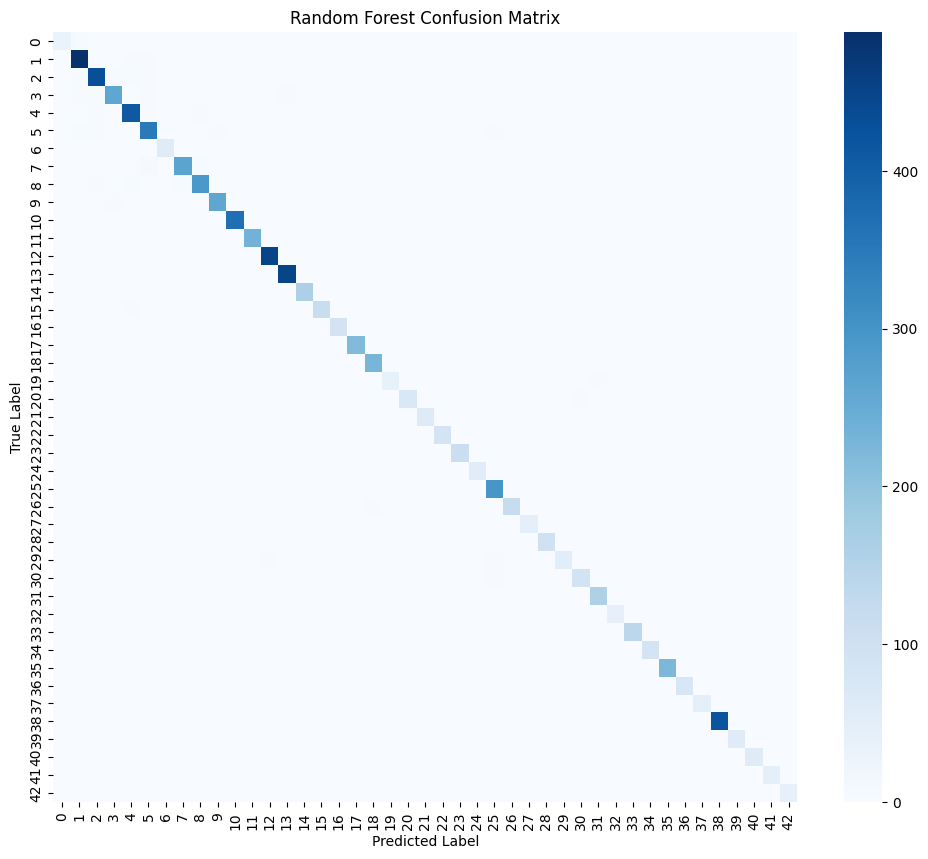

In [ ]:
rf_metrics = evaluate_model(
                    "Random Forest",
                    y_pred_rf,
                    y_t2
                 )


KNN
Accuracy  : 0.8693
Precision : 0.8764
Recall    : 0.8693
F1 Score  : 0.8705

Classification Report
              precision    recall  f1-score   support

           0       0.76      0.82      0.78        38
           1       0.87      0.89      0.88       496
           2       0.87      0.86      0.86       450
           3       0.75      0.77      0.76       280
           4       0.84      0.85      0.84       418
           5       0.68      0.88      0.77       364
           6       0.90      0.95      0.93        59
           7       0.76      0.86      0.81       278
           8       0.81      0.90      0.85       301
           9       0.89      0.92      0.90       268
          10       0.93      0.87      0.90       370
          11       0.92      0.79      0.85       236
          12       0.96      0.90      0.93       450
          13       0.95      0.94      0.95       452
          14       1.00      0.86      0.93       162
          15       0.86      0.

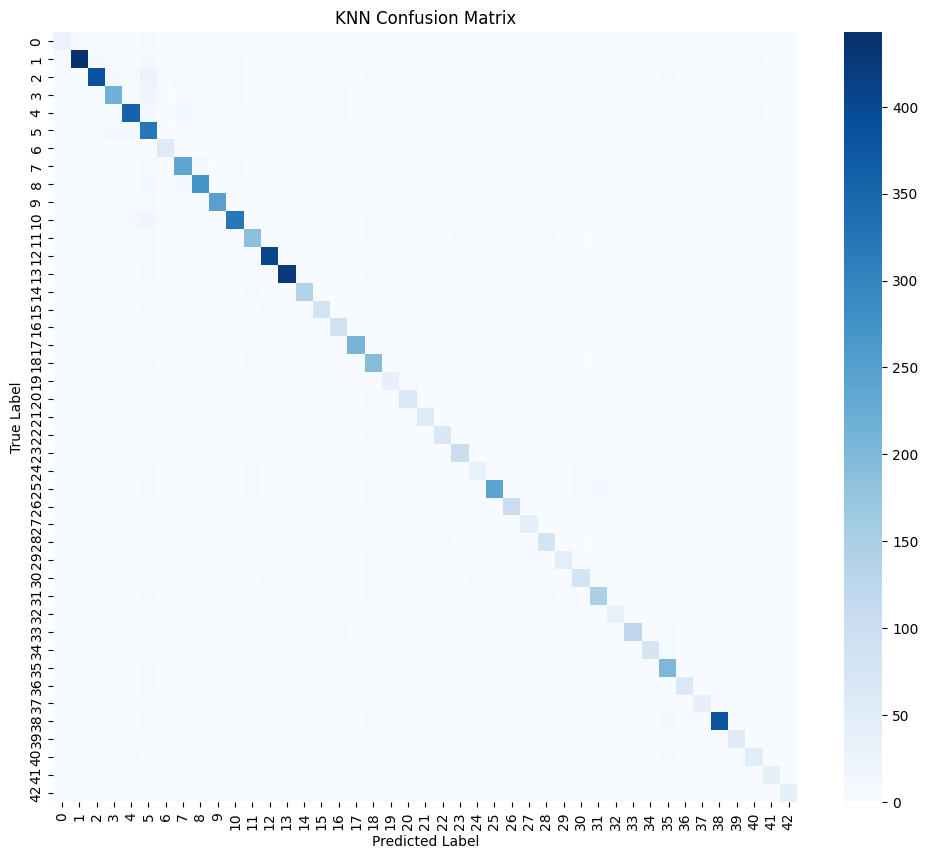

In [ ]:
knn_metrics = evaluate_model(
                    "KNN",
                    y_pred_knn,
                    y_t2
                  )


MobileNetV2
Accuracy  : 0.8447
Precision : 0.8546
Recall    : 0.8447
F1 Score  : 0.8447

Classification Report
              precision    recall  f1-score   support

           0       0.66      0.87      0.75        38
           1       0.83      0.88      0.86       496
           2       0.83      0.81      0.82       450
           3       0.66      0.82      0.73       280
           4       0.87      0.71      0.78       418
           5       0.83      0.78      0.80       364
           6       0.79      0.88      0.83        59
           7       0.89      0.79      0.84       278
           8       0.79      0.86      0.82       301
           9       0.97      0.78      0.86       268
          10       0.85      0.94      0.90       370
          11       0.82      0.74      0.78       236
          12       0.96      0.98      0.97       450
          13       0.99      0.94      0.97       452
          14       0.98      0.96      0.97       162
          15       0.94

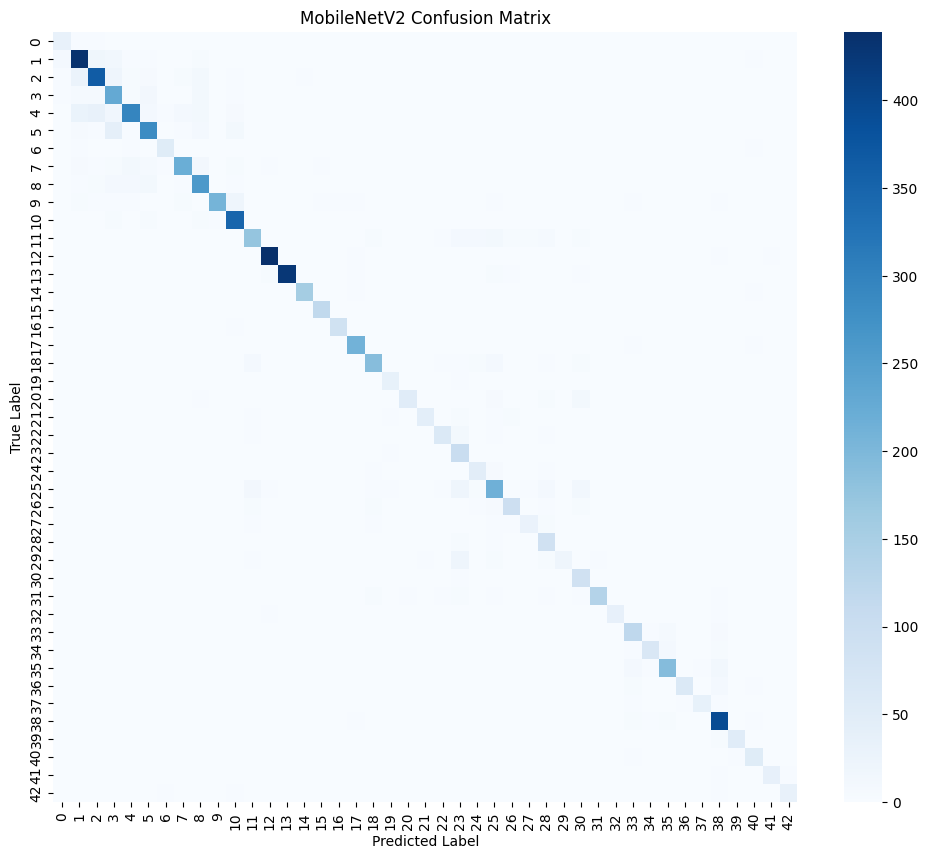

In [ ]:
mobilenet_metrics = evaluate_model(
                        "MobileNetV2",
                        y_pred_mobilenet,
                        y_t2
                     )


CNN
Accuracy  : 0.9731
Precision : 0.9744
Recall    : 0.9731
F1 Score  : 0.9733

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        38
           1       0.97      0.97      0.97       496
           2       0.99      0.90      0.94       450
           3       0.98      0.92      0.95       280
           4       0.98      0.97      0.97       418
           5       0.83      0.97      0.89       364
           6       0.95      1.00      0.98        59
           7       0.98      0.96      0.97       278
           8       0.96      0.97      0.97       301
           9       0.98      0.98      0.98       268
          10       0.97      0.99      0.98       370
          11       0.99      1.00      0.99       236
          12       0.97      1.00      0.99       450
          13       0.99      0.96      0.98       452
          14       0.99      1.00      1.00       162
          15       0.97      0.

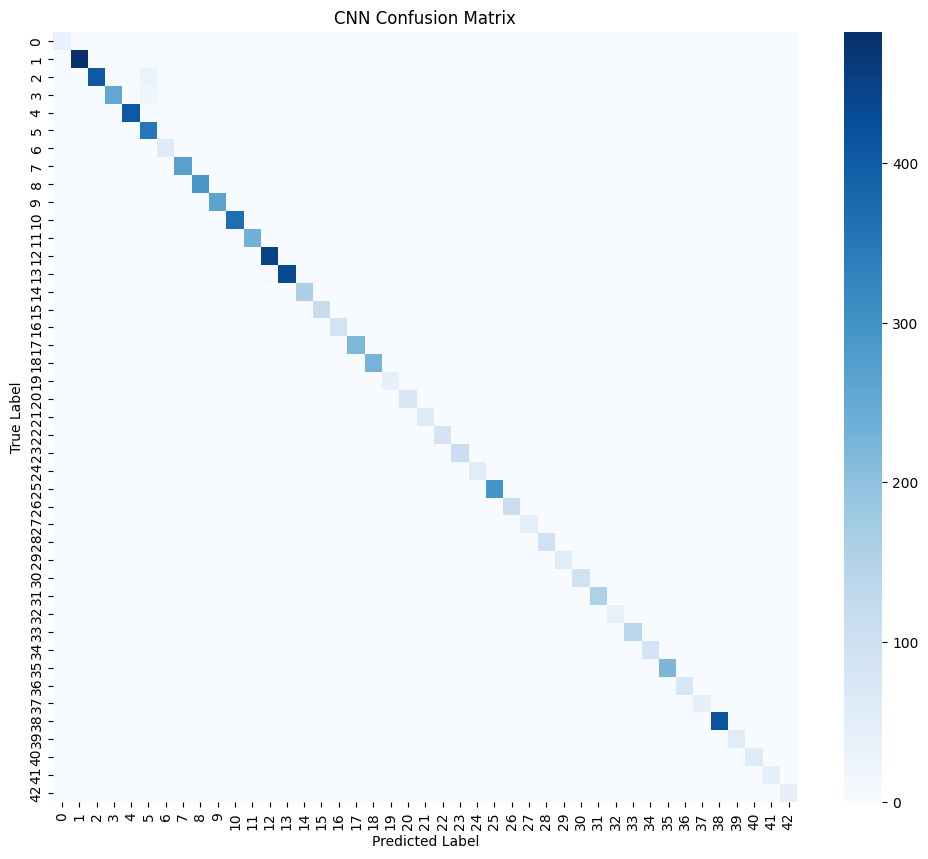

In [ ]:
cnn_metrics = evaluate_model(
                    "CNN",
                    y_pred_cnn,
                    y_t2
                  )

In [ ]:
import pandas as pd


results = pd.DataFrame({

'Model' : [

'Random Forest',
'KNN',
'CNN',
'MobileNetV2'

],


'Accuracy' : [

rf_metrics[0],
knn_metrics[0],
cnn_metrics[0],
mobilenet_metrics[0]

],


'Precision' : [

rf_metrics[1],
knn_metrics[1],
cnn_metrics[1],
mobilenet_metrics[1]

],


'Recall' : [

rf_metrics[2],
knn_metrics[2],
cnn_metrics[2],
mobilenet_metrics[2]

],


'F1 Score' : [

rf_metrics[3],
knn_metrics[3],
cnn_metrics[3],
mobilenet_metrics[3]

]

})


print(results)

           Model  Accuracy  Precision    Recall  F1 Score
0  Random Forest  0.981127   0.981280  0.981127  0.981093
1            KNN  0.869294   0.876435  0.869294  0.870529
2            CNN  0.973094   0.974444  0.973094  0.973264
3    MobileNetV2  0.844682   0.854607  0.844682  0.844691


In [ ]:
import joblib

# Save Scikit-Learn models
joblib.dump(rf_model, 'RF_Model.pkl')
joblib.dump(knn_model, 'KNN_Model.pkl')

# Save TensorFlow/Keras models
cnn_model.save('CNN_Model.keras')
mobilenet_model.save('MobileNetV2_Model.keras')

print("All models saved successfully!")

All models saved successfully!
